# TS convergence, many structures of one phase, one tolerance

`refine_many_structures_with_discovered_tolerance` from `phase_diagram_workflows.free_energies.ts_convergence.many`.

For a phase there is one structure per concentration, and the right tolerance is visible in the first bracket of all of them: the criteria fall into a low group (the crystal survived the heating) and a high group (it did not). The driver

1. runs the first bracket of **every** structure,
2. once all are done, finds the tolerance from their criteria **once** (`discover_tolerance`) and stores it in `tolerance.json` in the phase folder,
3. narrows every structure that is above it with `refine_temperature_bracket_with_resubmission`.

The tolerance is never recomputed for the narrower brackets: most of those are good, so their criteria have no gap, and a moving tolerance would change the verdict on brackets already judged.

Here the four "structures" are Al with slightly different lattice constants, standing in for four concentrations. They all survive the bracket, so there is **no** failing group and `discover_tolerance` has nothing to find; the driver then uses `fallback_tolerance`. In a real sweep that reaches into a transformation you would not give one and would let the gap decide. The coordinator job also needs an executor that resolves `Future` arguments (a cluster executor, or `SingleNodeExecutor` as here).

In [1]:
import sys
from pathlib import Path

# _common.py (shared settings) sits two levels up from this notebook
sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "_common.py").is_file())))
import _common

_common.setup_environment()


In [2]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
from executorlib import SingleNodeExecutor

from phase_diagram_workflows.free_energies.ts_convergence.many import (
    load_discovered_tolerance,
    refine_many_structures_with_discovered_tolerance,
)
from phase_diagram_workflows.free_energies.ts_convergence.plotting import plot_criteria_vs_concentration
from phase_diagram_workflows.free_energies.ts_convergence.single import ExecutorSpec

## 1. Inputs

In [3]:
LATTICE_CONSTANTS = {"a4.03": 4.03, "a4.05": 4.05, "a4.07": 4.07, "a4.09": 4.09}
structures = {name: _common.al_structure(a) for name, a in LATTICE_CONSTANTS.items()}
potential_df = _common.mishin_al_potential()
calphy_parameters = _common.calphy_parameters()
INITIAL_BRACKET = _common.INITIAL_BRACKET
print(list(structures), f"{len(next(iter(structures.values())))} atoms each, bracket {INITIAL_BRACKET}")

['a4.03', 'a4.05', 'a4.07', 'a4.09'] 32 atoms each, bracket (700.0, 720.0)


## 2. Submit everything with one call

`discover_tolerance` needs at least four criteria, hence four structures. `fallback_tolerance=0.0075` is what is used because there is no gap (section 1). `step_upper=5`, `max_iterations=1`: a structure above the tolerance is narrowed once.

In [4]:
working_directory = str(_common.results_directory("many"))
EXECUTOR_SPEC = ExecutorSpec(
    SingleNodeExecutor,
    {"hostname_localhost": True, "max_cores": 4, "cache_directory": os.path.join(working_directory, "executorlib_cache")},
)

submitted = refine_many_structures_with_discovered_tolerance(
    structures=structures,
    calphy_parameters=calphy_parameters,
    potential_df=potential_df,
    executor_spec=EXECUTOR_SPEC,
    working_directory=working_directory,
    initial_bracket=INITIAL_BRACKET,
    step_upper=5.0,
    max_iterations=1,
    fallback_tolerance=0.0075,
    coordinator_resource_dict={"cores": 1},   # the default also sets run_time_limit, which only the cluster executors accept
)
submitted

Input validation successful. Proceeding with calculation.


Input validation successful. Proceeding with calculation.


Input validation successful. Proceeding with calculation.
Input validation successful. Proceeding with calculation.


Input validation successful. Proceeding with calculation.
Input validation successful. Proceeding with calculation.


{'tolerance': 0.006938014383039658,
 'first_brackets_submitted': ['a4.03', 'a4.05', 'a4.07', 'a4.09'],
 'narrowing_submitted': ['a4.03', 'a4.07']}

## 3. What was decided

`tolerance.json` holds the tolerance, how it was found (`gap` or `fallback`) and the first-bracket criteria it was based on.

In [5]:
print(json.dumps(json.load(open(os.path.join(working_directory, "tolerance.json"))), indent=1))
TOLERANCE = load_discovered_tolerance(working_directory)
assert TOLERANCE is not None

{
 "tolerance": 0.006938014383039658,
 "method": "gap",
 "initial_bracket": [
  700.0,
  720.0
 ],
 "first_bracket_criteria": {
  "a4.03": 0.0168969630852098,
  "a4.05": 0.0028478654517303,
  "a4.07": 0.0123487424076498,
  "a4.09": 0.0038980522866398
 }
}


,structure,t_low,t_high,criterion
0,a4.03,700.0,720.0,0.016897
1,a4.03,700.0,715.0,0.006197
2,a4.05,700.0,720.0,0.002848
3,a4.07,700.0,720.0,0.012349
4,a4.07,700.0,715.0,0.006161
5,a4.09,700.0,720.0,0.003898


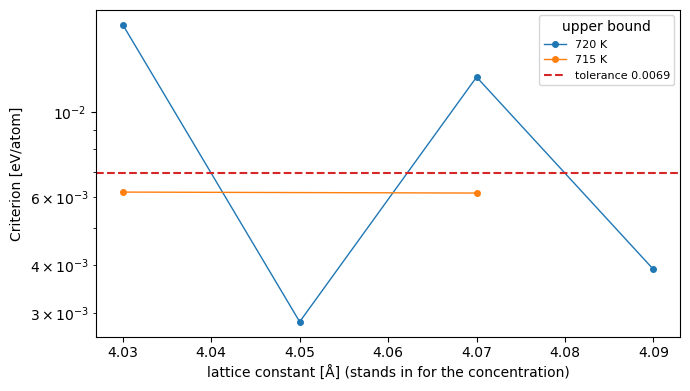

In [6]:
logs = []
for name, a in LATTICE_CONSTANTS.items():
    log = pd.read_csv(os.path.join(working_directory, name, "bracket_log.csv"))
    log["c"] = a
    log["structure"] = name
    logs.append(log)
history = pd.concat(logs, ignore_index=True)
display(history[["structure", "t_low", "t_high", "criterion"]])

fig, ax = plot_criteria_vs_concentration(history, tolerance=TOLERANCE)
ax.set_xlabel("lattice constant [Å] (stands in for the concentration)")
plt.show()

## 4. Calling again

Resumes from disk: every first bracket has a result and `tolerance.json` exists, so nothing is recomputed and the tolerance is not changed. Only structures that are still above it are narrowed (up to `max_iterations`).

In [7]:
again = refine_many_structures_with_discovered_tolerance(
    structures=structures, calphy_parameters=calphy_parameters, potential_df=potential_df,
    executor_spec=EXECUTOR_SPEC, working_directory=working_directory, initial_bracket=INITIAL_BRACKET,
    step_upper=5.0, max_iterations=1, fallback_tolerance=0.0075,
    coordinator_resource_dict={"cores": 1},
)
print(again)
assert again["tolerance"] == TOLERANCE and again["first_brackets_submitted"] == []

{'tolerance': 0.006938014383039658, 'first_brackets_submitted': [], 'narrowing_submitted': []}
